In [ ]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [56]:
import sys

sys.path.append('/g/stegle/spiljak/cellina_tutorial/cellina-reproducibility/notebooks/application') #/g/stegle/spiljak/cellina_tutorial/cellina-reproducibility/scripts

In [57]:
sys.path.append('/g/stegle/spiljak/cellina_tutorial/cellina-reproducibility/scripts')

In [58]:
from helpers import _normalize_counts, safe_log2_fold_change, compute_correlations, subsample_adata

In [59]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
DATA_ROOT = os.environ.get("DATA_ROOT", ".")
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split

from cellina_graph import CellinaModel
from utils import set_seed
from train_loo import preprocess_adata

In [60]:
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 16
plt.rcParams['figure.dpi'] = 50


In [61]:
import cellina_graph
cellina_graph.__version__

'0.0.10'

# Get dataset

In [62]:
set_seed(0)

In [63]:
adata = sc.read("/g/stegle/spiljak/data/hca_subsampled_20k.h5ad")
adata.obs_names_make_unique()

# Assign 2D spatial coordinates based on anatomical heart region (with noise)
region_coords = {
    'LV': (200, 200),
    'RV': (800, 200),
    'LA': (200, 800),
    'RA': (800, 800),
    'AX': (500, 100),
    'SP': (500, 500),
}
np.random.seed(42)
coords = np.array([region_coords.get(r, (500, 500)) for r in adata.obs['region']], dtype=float)
coords += np.random.normal(0, 80, coords.shape)
adata.obsm['spatial'] = coords

In [64]:
adata

AnnData object with n_obs × n_vars = 20000 × 26662
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'
    obsm: 'spatial'

In [65]:
print(adata.obs.columns.tolist())

['NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used']


In [66]:
adata = preprocess_adata(adata, n_top_genes=2000, labels_key='cell_type', domains_key='region')    #normally here was a neghbourhood preprocessing function, but since preprocess_data does not really deal with that, I am gonna try a different fucntion below

/g/stegle/spiljak/cellina_tutorial/cellina-reproducibility/scripts/train_loo.py:175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")


In [67]:
from cellina_graph._spatial_utils import spatial_neighbors

spatial_neighbors(adata, bandwidth=100, max_neighbours=200, standardize=False)

In [68]:
adata

AnnData object with n_obs × n_vars = 20000 × 2000
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_type_colors', 'hvg', 'log1p'
    obsm: 'spatial'
    layers: 'counts'
    obsp: 'spatial_connectivities'

In [69]:
labels_key = 'cell_type'
domains_key = 'region'
batch_key = 'donor'

In [70]:
fig_save_path = "/g/stegle/spiljak/data/figures/application"

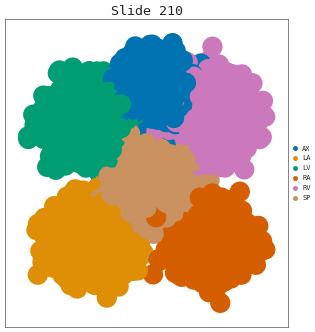

In [71]:
fig, ax = plt.subplots(figsize=(8, 8))  # width x height in inches

sc.pl.spatial(
    adata,
    color=domains_key,
    ax=ax,
    spot_size=100,
    title=f"Slide 210",
    show=False,
)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])
plt.show()

#fig.savefig("", bbox_inches='tight')

## Data splits

In [72]:
split = "random"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    holdout_ct = "Fibroblast"
    is_tumor_region  = adata.obs[domains_key].str.contains("CRC", regex=True)
    is_holdout_ct = adata.obs[labels_key] == holdout_ct

    # Combine for test set
    test_mask = (is_tumor_region) & (is_holdout_ct)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [73]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [74]:
validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

# Train

In [75]:
model_name = "mark1"

In [76]:
model_base_path = f"/g/stegle/spiljak/cellina_tutorial/data/models/{model_name}"

In [77]:
from scvi.train._callbacks import SaveCheckpoint, EarlyStopping

model_args = {
    'adata': adata,
    'n_latent': 64,
    'n_layers': 3,
    'use_observed_lib_size': True,
    'condition_on_intrinsic': False,
    'gene_likelihood': 'nb',
    'classifier_lambda': 1.,
    'discriminator_lambda': 1.,
    }
train_args = {'max_epochs': 100,
              'batch_size': 4096,
              'check_val_every_n_epoch': 1,
              'early_stopping': True,
              'devices': [0],
              'datasplitter_kwargs': {
                  "external_indexing": [train_idx, val_idx, test_idx],
                  },
              'enable_checkpointing':True,
              'callbacks': [
                  SaveCheckpoint(
                      monitor='vae_loss_validation',
                      dirpath=f"{model_base_path}",
                      load_best_on_end=True,
                      ),
                  EarlyStopping(
                      monitor="vae_loss_validation",
                      patience=5,
                      mode="min",
                    ),
                ],
    }

plan_kwargs = {
    'lr': 1e-3,
    'normalize_losses': True
    }

In [78]:
CellinaModel.setup_anndata(adata,
                           batch_key=batch_key,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_connectivities_key="spatial_connectivities",
                           layer='counts')

In [79]:
model = CellinaModel(
    **model_args, 
)
model.train(**train_args, plan_kwargs=plan_kwargs)

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /g/stegle/spiljak/programs/miniforge3/envs/cellina-g ...
INFO: GPU available: True (cuda), used: True
2026-05-27 10:59:56 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-27 10:59:56 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-05-27 10:59:56 | [INFO] HPU available: False, using: 0 HPUs
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `s

Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
2026-05-27 10:59:59 | [INFO] 
Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

INFO     File                                                                                                      
         /g/stegle/spiljak/cellina_tutorial/data/models/mark1/epoch=99-step=792-vae_loss_validation=527.00482177734
         38/model.pt already downloaded                                                                            
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /g/stegle/spiljak/programs/miniforge3/envs/cellina-g ...
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary

# Inference and clustering

In [93]:
#loading the trained cellina model
checkpoint_name = os.listdir(model_base_path)[0]
model = CellinaModel.load(f"{model_base_path}/{checkpoint_name}", adata=adata)

INFO     File                                                                                                      
         /g/stegle/spiljak/cellina_tutorial/data/models/mark1/epoch=99-step=792-vae_loss_validation=527.00482177734
         38/model.pt already downloaded                                                                            
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /g/stegle/spiljak/programs/miniforge3/envs/cellina-g ...
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary

In [103]:
adata.obsm['cellina_basal'] = model.get_latent_representation(adata=adata, latent_key='z', batch_size=4096)
adata.obsm['cellina_spatial'] = model.get_latent_representation(adata=adata, latent_key='s', batch_size=4096)
# adata.obsm['cellina_latent'] = model.get_latent_representation(adata=adata, batch_size=4096)

### Latent visualization

In [104]:
adata_sub = subsample_adata(adata, fraction=0.5)


In [105]:
sc.pp.neighbors(adata_sub, use_rep='cellina_basal')
sc.tl.umap(adata_sub)

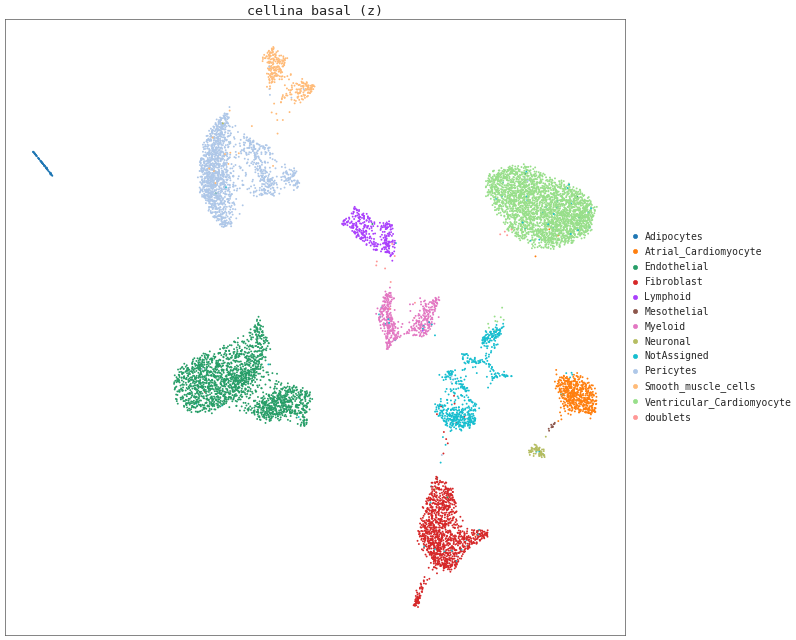

In [106]:
plt.rcParams['figure.figsize'] = (16, 16)
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, show=False, size=30, legend_fontsize=14, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

#fig.savefig(f"{fig_save_path}/crc_210_umap_basal_ct.png", bbox_inches='tight')

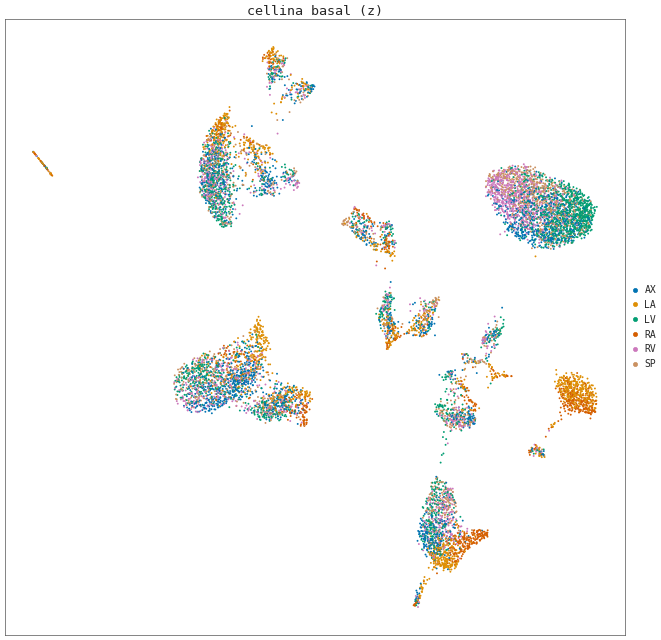

In [107]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, show=False, size=30, legend_fontsize=14,title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

#fig.savefig(f"{fig_save_path}/{slide_id}_umap_basal_niche.png", bbox_inches='tight')

In [ ]:
sc.pp.neighbors(adata_sub, use_rep='cellina_spatial')
sc.tl.umap(adata_sub)

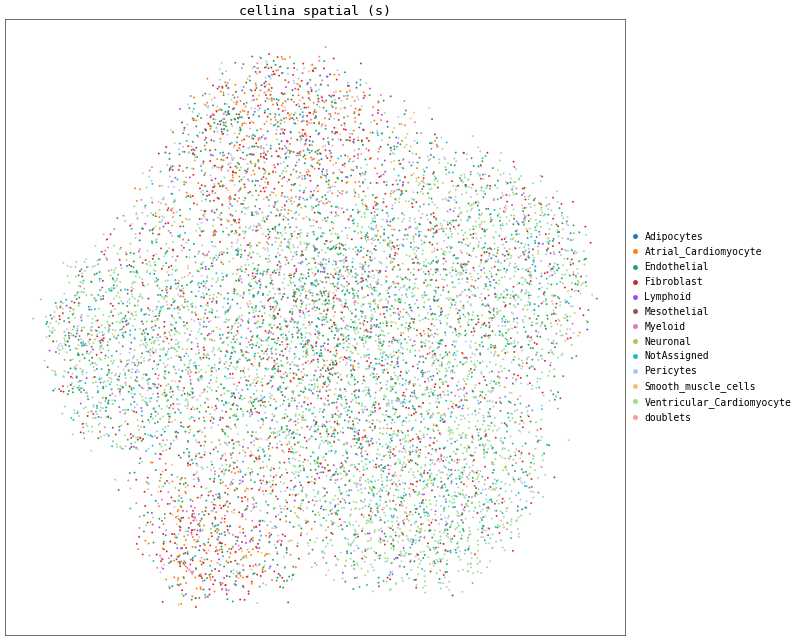

In [ ]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, show=False, size=30, legend_fontsize=14, title="cellina spatial (s)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

#fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_ct.png", bbox_inches='tight')

In [ ]:
palette = {
    # Control
    'REF': '#E69F00',

    # CRC
    'CRC': "#0075D5",

    # RA
    'RA': "#00B221",
    
    #AX
    'AX': "#FF00FF",

    #LA
    'LA': "#00FFFF",
    
    #SP
    'SP': "#FF0000",

    #LV
    'LV': "#0000FF",
    #RV
    'RV': "#FFFF00",



}

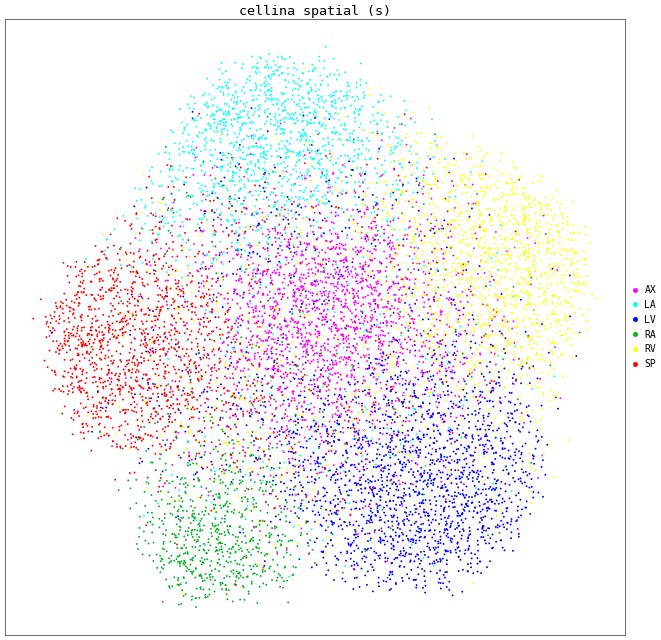

In [ ]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, show=False, size=30, legend_fontsize=14, title="cellina spatial (s)", palette=palette)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

#fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_niche.png", bbox_inches='tight')

The 4 plots are two pairs — each pair asks the same two questions but about a different latent space:

**Basal latent `z` (plots 1 & 2)** — UMAP built from `cellina_basal`, which is the model's "intrinsic" representation of each cell. It captures pure transcriptional identity, stripped of spatial context. So:
- Plot 1: colored by `coarse_type` (cell type) — you'd expect clean separation here, T cells away from fibroblasts etc.
- Plot 2: colored by `typ_clean` (tissue domain: CRC/REF/TVA) — if the basal space is doing its job, these should *not* separate well, meaning the model successfully disentangled cell identity from spatial context.

**Spatial latent `s` (plots 3 & 4)** — UMAP built from `cellina_spatial`, which captures where a cell "lives" in tissue context rather than what type it is. So:
- Plot 3: colored by `coarse_type` — ideally cells should *mix* here, since spatial context cuts across cell types
- Plot 4: colored by `typ_clean` (CRC/REF/TVA) — you'd expect clean separation here, since the spatial latent should capture which tissue region/domain a cell belongs to

In short: **`z` should separate by cell type, `s` should separate by tissue domain.** These 4 plots are essentially a sanity check that the model's two latent spaces have learned what they were supposed to learn.

--> problem is that I simulate domains so if results make or dont makes sense in this area don't lose sleep over it<---

## Hotspot clusters

In [109]:
import sys, importlib

# Remove cached version of the installed plotting package
if 'plotting' in sys.modules:
    del sys.modules['plotting']

# Insert at front so it takes priority over site-packages
sys.path.insert(0, '/g/stegle/spiljak/cellina_tutorial/cellina-reproducibility/scripts')

import pandas as pd
import decoupler as dc
import hotspot
from plotting import plot_custom_umap

In [110]:
adata_crc = adata[adata.obs[domains_key].str.contains('LV')].copy() #region key, izvorno je tu bia CRC ali taj domain u momo datasetu nema

In [111]:
set_seed(0)  # ensure reproducible hotspot KNN and module detection

In [96]:
adata_crc

AnnData object with n_obs × n_vars = 4368 × 2000
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used', 'is_holdout', '_scvi_batch', '_scvi_labels', '_scvi_domains'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'region_colors', '_scvi_uuid', '_scvi_manager_uuid', 'spatial_connectivities_key'
    obsm: 'spatial', 'cellina_basal', 'cellina_spatial'
    layers: 'counts'
    obsp: 'spatial_connectivities'

In [97]:
print(adata_crc.shape)
print(adata_crc.layers["counts"].shape)

(4368, 2000)
(4368, 2000)


In [112]:
print(list(adata_crc.obsm.keys()))
print(list(adata.obsm.keys()))

['spatial', 'cellina_basal', 'cellina_spatial']
['spatial', 'cellina_basal', 'cellina_spatial']


In [114]:
sc.pp.filter_genes(adata_crc, min_cells=1)  # removes genes with 0 counts in all cells
hs = hotspot.Hotspot(
    adata_crc,
    layer_key="counts",
    model='danb',
    latent_obsm_key="cellina_spatial",
    umi_counts_obs_key="n_counts"
)

hs.create_knn_graph(
    weighted_graph=False, n_neighbors=30,
)

/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/hotspot/hotspot.py:98: UserWarning: Hotspot will work faster when counts are a csr sparse matrix.
  warnings.warn(


In [115]:
hs_results = hs.compute_autocorrelations(jobs=24)

100%|██████████| 1952/1952 [00:02<00:00, 692.77it/s] 


In [116]:
# Select the genes with significant lineage autocorrelation
top_k = 1200
hs_genes = hs_results.loc[hs_results.FDR < 0.05].head(top_k).index

In [118]:
# Compute pair-wise local correlations between these genes
load_lcz = False
base_dir = f'{model_base_path}/hotspot'
lcz_path = f'{base_dir}/hotspot_lcz_crc.csv'

if load_lcz:
    lcz = pd.read_csv(lcz_path, index_col=0)
    hs.local_correlation_z = lcz
else:
    lcz = hs.compute_local_correlations(hs_genes, jobs=24)
    os.makedirs(base_dir, exist_ok=True)
    lcz.to_csv(lcz_path)

Computing pair-wise local correlation on 241 features...


100%|██████████| 28920/28920 [00:03<00:00, 9239.76it/s] 


In [119]:
modules = hs.create_modules(min_gene_threshold=100, core_only=True, fdr_threshold=0.05)

In [120]:
module_scores = hs.calculate_module_scores()

module_scores.head()

Computing scores for 1 modules...


100%|██████████| 1/1 [00:00<00:00,  2.83it/s]


,1
AGGTTACCAGATAAAC-1-H0037_LV,-1.095684
AGCCTAATCTACCAGA-1-HCAHeart7835148,-0.327448
TGGGAAGAGTCGAGTG-1-HCAHeart7829978,0.176664
TGGCTGGCATGGGAAC-1-HCAHeart7702873,0.510856
TCCATCGGTTGGACCC-1-H0026_LV_V3,-0.516017


In [121]:
module_cols = []
for c in module_scores.columns:
    key = f"Module {c}"
    adata_crc.obs[key] = module_scores[c]
    module_cols.append(key)

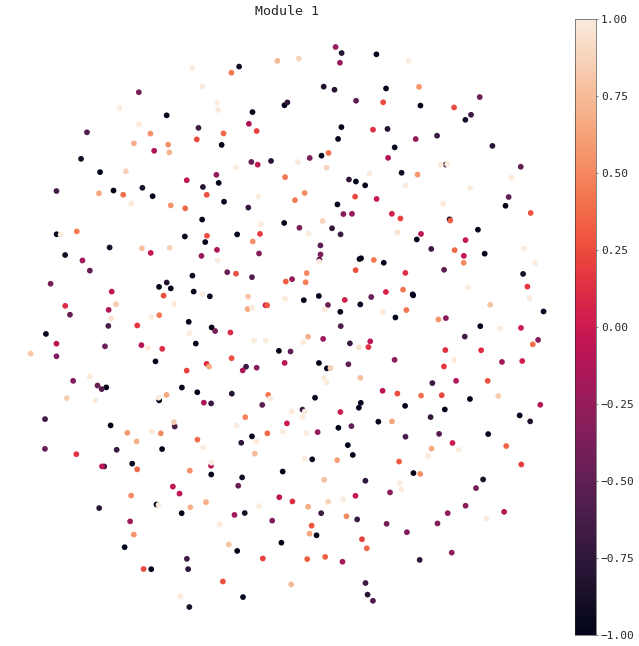

In [122]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=module_cols,frameon=False, vmin=-1, vmax=1, wspace=0.2
)

In [133]:
adata_crc.obs.columns

Index(['NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender',
       'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region',
       'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states',
       'Used', 'is_holdout', '_scvi_batch', '_scvi_labels', '_scvi_domains',
       'Module 1', 'top_module'],
      dtype='object')

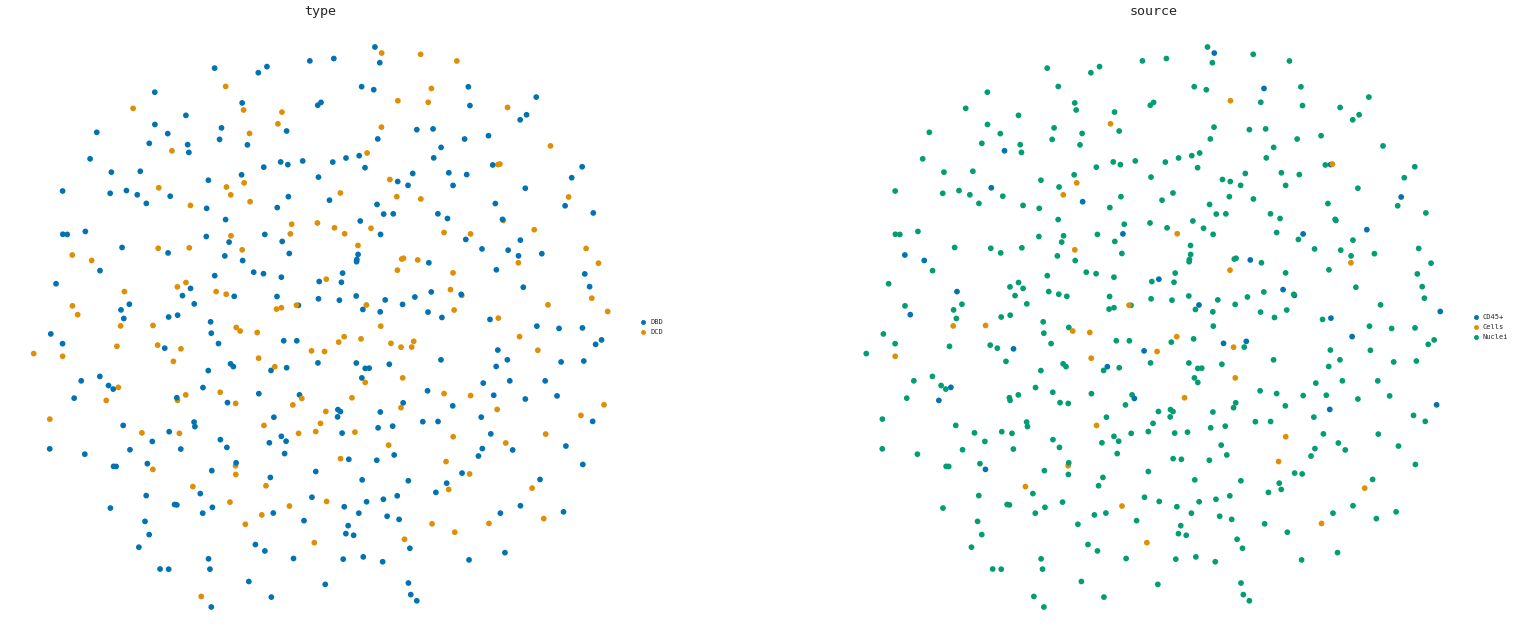

In [135]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=['type', 'source'], frameon=False, vmin=-1, vmax=1, wspace=0.2
)

In [129]:
module_scores_epi = module_scores.loc[adata_crc.obs_names]

In [130]:
adata_crc.obsm['module_scores'] = module_scores_epi.values

In [131]:
top_modules = module_scores.idxmax(axis=1)

# Add to adata.obs
adata_crc.obs["top_module"] = top_modules.astype(str)
adata_crc.obs["top_module"] = adata_crc.obs["top_module"].astype("category")

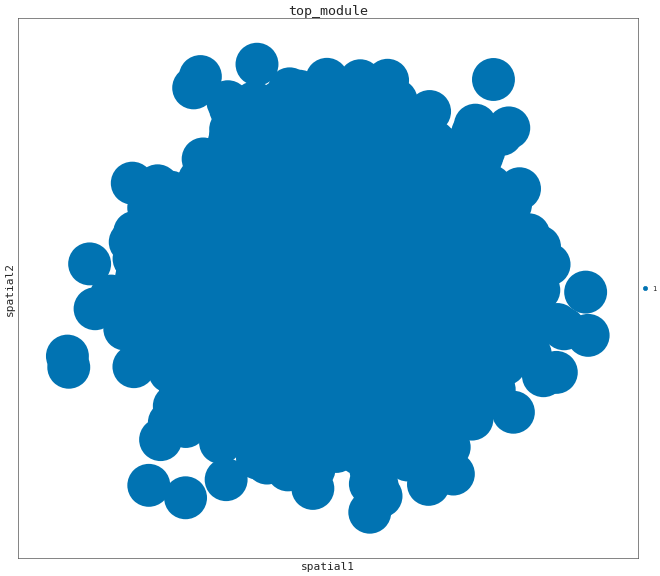

In [136]:
# Plot
sc.pl.spatial(
    adata_crc,
    color=["top_module"],
    palette=None,
    spot_size=50,
    show=True
)

In [137]:
# top module to f{CRC{}}
adata_crc.obs['microenvironment'] = adata_crc.obs['top_module'].apply(lambda x: f"CRC{x}")

In [138]:
adata_crc.obs['microenvironment'].value_counts()

microenvironment
CRC1    4368
Name: count, dtype: int64

### Remap

In [141]:
typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata_sub.obs_names)  # NaN for non-CRC cells

adata_sub.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata_sub.obs['type'].astype(str))
)

typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata.obs_names)  # NaN for non-CRC cells
adata.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata.obs['type'].astype(str))
)
    

In [142]:
adata.obs['microenvironment'].value_counts()

microenvironment
DCD     9317
DBD     6315
CRC1    4368
Name: count, dtype: int64

/scratch/jobs/54840350/ipykernel_2948782/333694513.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')


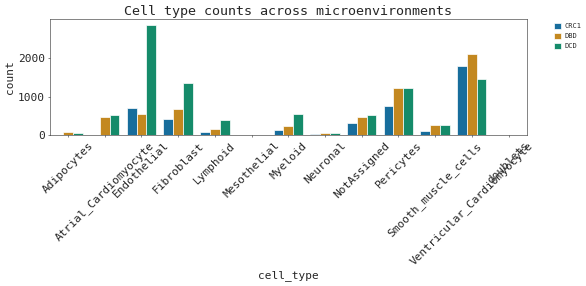

In [143]:
# Plot how many cells of each microenvironment are present in each cell type
celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(data=celltype_microenv_counts, x=labels_key, y='count', hue='microenvironment')
plt.xticks(rotation=45)
plt.title("Cell type counts across microenvironments")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Counterfactuals - CRC_global vs. CRC_microenv

In [144]:
celltypes = ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'T_cell']
microenvironments = [m for m in adata.obs['microenvironment'].unique() if 'CRC' in m]
results = {k: adata[adata.obs[labels_key] == k] for k in celltypes}

In [145]:
print(microenvironments)

['CRC1']


In [146]:
for ct in tqdm(celltypes, desc=f"Cell types"):
    # Control set is same - only target changes (either crc_all or microenv labels)
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    is_celltype = adata.obs[labels_key].astype(str) == ct
    
    mask_control = ~is_tumor_region & is_celltype
    # mask_control = adata.obs[domains_key].astype(str).str.contains('REF', regex=True) & is_celltype # NOTE: changed from ~CRC to REF
    
    idx_control = np.where(mask_control.values)[0]

    # 1. Compute counterfactuals for global crc
    mask_target = is_tumor_region
    #mask_target = is_tumor_region & is_celltype
    idx_target = np.where(mask_target.values)[0]
    args = {
                "adata": adata,
                "indices": idx_control,
                "neighbour_indices": idx_target,
                "batch_size": 4096,
                "seed": 0,
            }
    results[ct].obsm['recon_x'] = model.get_normalized_expression(adata=results[ct], batch_size=4096, library_size=1e4)
    results[ct].uns[f'counterfactual_x_global'] = model.get_counterfactual_expression(**args, library_size=1e4)
    results[ct].uns[f'counterfactual_latents_global'] = model.get_counterfactual_latents(**args, latent_key='shifted')

    # 2. Loop over microenvironments
    for microenv in tqdm(microenvironments, desc=f"Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        mask_target = is_in_microenv
        #mask_target = is_in_microenv & is_celltype
        idx_target = np.where(mask_target.values)[0]
        args["neighbour_indices"] = idx_target
        results[ct].uns[f'counterfactual_x_{microenv}'] = model.get_counterfactual_expression(**args, library_size=1e4)
        results[ct].uns[f'counterfactual_latents_{microenv}'] = model.get_counterfactual_latents(**args, latent_key='shifted')

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(
Cell types:   0%|          | 0/5 [00:00<?, ?it/s]


TypeError: CellinaModel.get_counterfactual_expression() got an unexpected keyword argument 'adata'

In [ ]:
# _normalize_counts, safe_log2_fold_change, compute_correlations imported from helpers (cell 2)


In [ ]:
summary = []
deg = 200

for ct, dataset in tqdm(results.items(), desc="Computing correlations"):
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    mask_control = ~dataset.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    # mask_control = dataset.obs[domains_key].astype(str).str.contains('REF', regex=True) # NOTE: change from ~CRC to REF?

    control = dataset.layers['counts'].todense()[mask_control]
    control = np.asarray(control)
    
    is_ct = dataset.obs[labels_key].astype(str) == ct
    #mask_target = is_tumor_region & is_ct
    mask_target = is_tumor_region
    target = adata.layers['counts'].todense()[mask_target]
    target = np.asarray(target)

    counterfactual = dataset.uns['counterfactual_x_global']
    pear_global, spear_global = compute_correlations(control, target, counterfactual, deg=deg)

    summary.append({
        "cell_type": ct,
        "label": "CRC_global",
        "pearson": np.round(pear_global, 4),
        "spearman": np.round(spear_global, 4)
    })

    for microenv in tqdm(microenvironments, desc="Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        
        #mask_target = is_in_microenv & is_ct
        mask_target = is_in_microenv
        target = adata.layers['counts'].todense()[mask_target]

        target = np.asarray(target)
        counterfactual = dataset.uns[f'counterfactual_x_{microenv}']
        pear_microenv, spear_microenv = compute_correlations(control, target, counterfactual, deg=deg)
        summary.append({
            "cell_type": ct,
            "label": microenv,
            "pearson": np.round(pear_microenv, 4),
            "spearman": np.round(spear_microenv, 4)
        })

In [ ]:
summary_df = pd.DataFrame(summary)

In [ ]:
print(summary_df)

In [ ]:
# Save df
summary_df.to_csv(f"../../results/microenvironments_{slide_id}.csv", index=False)

## Save outputs

In [149]:
# ── Save Part 1 outputs ────────────────────────────────────────────────────
import pickle, os

os.makedirs("output", exist_ok=True)

# Save annotated AnnData (includes obsm latents + obs microenvironment)
adata.write_h5ad("output/adata_with_microenv.h5ad")
print("Saved adata to output/adata_with_microenv.h5ad")

# Save Hotspot object (modules, results, etc.)
with open("output/hotspot.pkl", "wb") as _f:
    pickle.dump(hs, _f)
print("Saved hotspot to output/hotspot.pkl")

# Save per-cell-type results dict (AnnData objects with .uns counterfactuals)
with open("output/results.pkl", "wb") as _f:
    pickle.dump(results, _f)
print("Saved results dict to output/results.pkl")

print(f"Model checkpoint saved at: {model_base_path}")


Saved adata to output/adata_with_microenv.h5ad
Saved hotspot to output/hotspot.pkl
Saved results dict to output/results.pkl
Model checkpoint saved at: /g/stegle/spiljak/cellina_tutorial/data/models/mark1
